## Processing the results

First, we'll read in the data from the file and do some minimal cleanup. Load the necessary tools.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
#from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Now read in the data - including the spatial data involved with the creation of the simulation.

In [16]:
# set up the filenames!

rawDataDir = "/Users/swise/workspace/takamatsu/data/takamatsuTsunamiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/output/results/"

waterFloodedFile = rawDataDir + "flooded_reproj.shp"
roadsFile = rawDataDir + "roads_simple.shp"
shelterFile = rawDataDir + "sheltersWithParking.shp"
#stationsFile = rawDataDir + "trainStationsWithPassengers.shp"

# read in the list of files from the directory

workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder

roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
shelters = geopandas.read_file(shelterFile)
#stations = geopandas.read_file(stationsFile)

Let's create a helper function to extract the relevant information from the raw records!

In [215]:
# helper function
def extractEvacTime(s, totalSteps):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "BEGIN_EVACUATING" in record:
        startTime = record["BEGIN_EVACUATING"]
    else:
        startTime = record["START"]
    finishTime = totalSteps
    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "DONE" in record:
        finishTime = record["DONE"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

Does it work? Let's try it on one example.

In [199]:
f = "out_params_default_txt_vertEvac0.txt" # hard code it to be sure you get a proper example
f_roads = "out_params_default_txt_vertEvac0_roaduse_5.txt"

raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
raw_road_data = pd.DataFrame(pd.read_csv(workingDir + f_roads, sep='\t', header=None))



In [200]:
raw_road_data = raw_road_data.rename(columns={0: "roads", 1: "usage"})

#raw_road_data.columns
raw_road_data["usage"] = [np.fromstring(x[1:-1], dtype=int, sep=', ') for x in raw_road_data["usage"]]

record_time_step = int(f_roads.split('_')[-1].replace(".txt", ""))

# how many steps were recorded - based on how frequently the roads were checked
total_sim_time = len(raw_road_data["usage"][0]) * record_time_step


In [201]:
evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
evacTime_evacuated = [extractEvacTime(s, total_sim_time) for s in evacuees["evacuatingRecord"]]

still_evacuating = raw_data[raw_data["status"] == "Evacuating"].reset_index()
evacTime_evacuating = [extractEvacTime(s, total_sim_time) for s in still_evacuating["evacuatingRecord"]]

#trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()


What does an evacuation record look like, just as an example?

In [202]:
evacuaters = raw_data[raw_data["evacuatingRecord"].notna()]
e = evacuaters["evacuatingRecord"]
e.get(4)

'BEGIN_EVACUATING:0.0,EVAC_ORDER_PROMPTED_AT:0,MOVE_TO_HOME_FAILED_BUT_WILL_RETRY:0,ARRIVED_HOME_PREP_STARTED:1,FINISHED_PREP_START_EVACUATING:2,ENTER_SHELTER:16,FINISH_EVAC:17,DONE:17,SET_TO_INUNDATED:60,FLOOD_PROMPTED_AT:60'

In [203]:
pd.unique(raw_data["flooded"])

array(['inZone', 'notSubmerged', 'inZone_verticalEvac'], dtype=object)

Ok, go through the files and pull out the evacuating times.

In [204]:
evacueeFullData = []
evacuatingFullData = []
numTrapped = []

# extract them
for f in files:
    
    print(f)
    
    if not (f.startswith("out_params_default") and f.endswith("txt")) or "trackedAgents" in f or "roaduse" in f or "heatmap" in f:
        continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    
    # successful evacuees
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evacTime = [extractEvacTime(s, total_sim_time) for s in evacuees["evacuatingRecord"]]
    evacueeFullData.append(evacTime)
    
    # incomplete evacuations
    evacuees = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    evacTime = [extractEvacTime(s, total_sim_time) for s in evacuees["evacuatingRecord"]]
    evacuatingFullData.append(evacTime)
    
    # trapped
    trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    numTrapped.append(len(trapped))
       
#len(evacueeFullData)
print(numTrapped)
if(len(evacueeFullData) == 0):
    print("Did you remember to update the filename prefix?")
else:
    len(evacueeFullData[0])

.DS_Store
out_params_default_txt_vertEvac0_trackedAgents_.txt
out_params_default_txt_vertEvac0.txt
out_params_default_txt_vertEvac0_roaduse_5.txt
[0]


### Trapped - NOT IN USE

len(numTrapped)

fig, ax = plt.subplots()
ax.set_title('Number of people trapped by end of simulation')
ax.boxplot(numTrapped, vert=False, labels=['50 runs'])
trappedFilename = "trappedDist.png"
plt.savefig(trappedFilename, format="png", dpi=720)

### Vertical Evacuation - Times

Text(0, 0.5, 'number of evaucees')

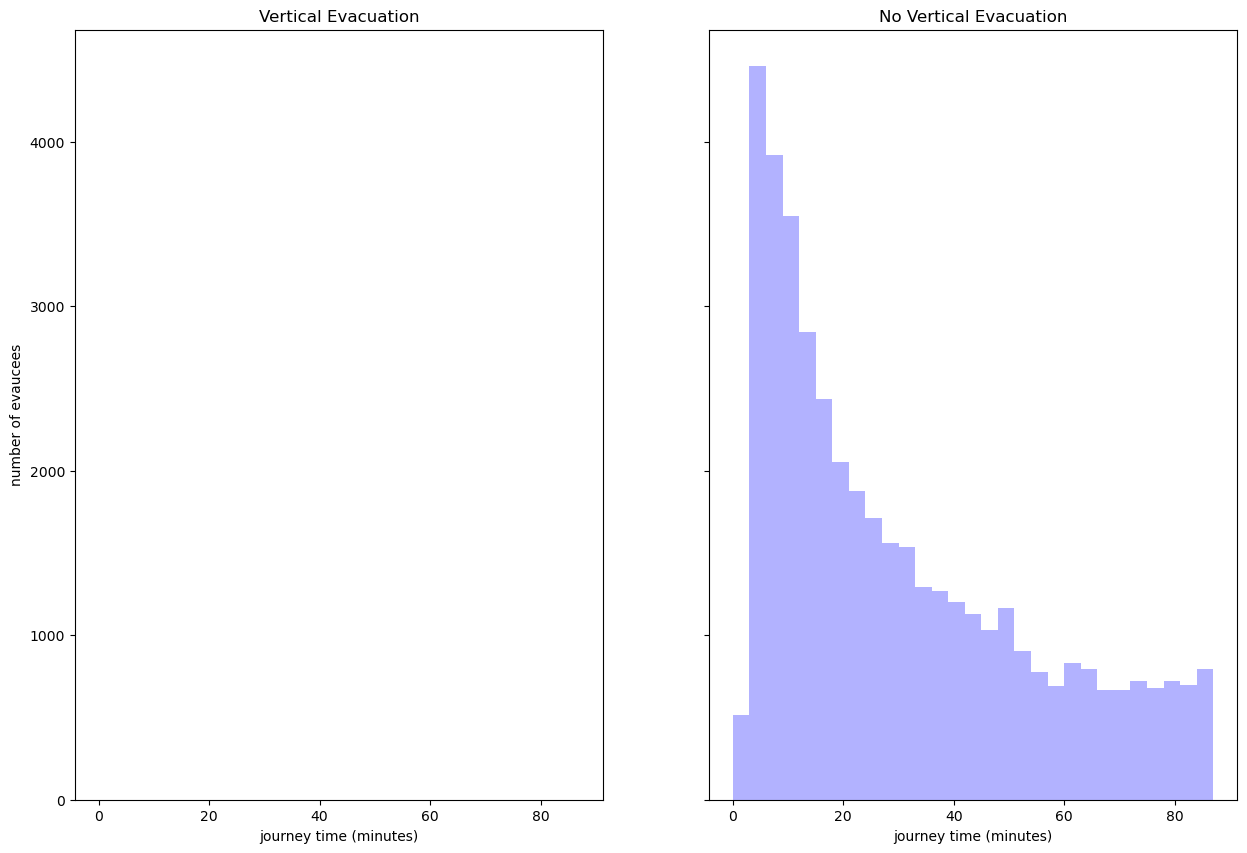

In [205]:
# pull out the noVert and vertEvac separately; make two plots and, for each instance, plot them on either side for journey times
vertEvac = ["_vertEvac" in f for f in files]
colors = ["red", "blue"]

fig, axs = plt.subplots(ncols=2, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
xbins = np.arange(0, 90, 3)
for index, val in enumerate(evacueeFullData):
    myAxis = 1
    if(vertEvac[index]):
        myAxis = 0        
    axs[myAxis].hist(val, bins=xbins, alpha=.3, color=colors[myAxis])
axs[0].set_title("Vertical Evacuation")
axs[1].set_title("No Vertical Evacuation")
for ax in axs:
    ax.set_xlabel("journey time (minutes)")
axs[0].set_ylabel("number of evaucees")

### By Attribute

Make it possible to extract by attributes

In [206]:
def selectOnAttribute(df, targetValues, waterFile = None, exclude=False):
    
    myDf = df
    
    # select on the flooding scenario?
    if waterFile is not None:
        # pull out the runs on a specific water setting
        myDf = df[df["waterShapefile"] == waterFile]

    # make sure there's actually something to select!
    if len(targetValues) == 0:
        return myDf
        
    # iterate through, selecting on these
    for i, j in targetValues.items():
        
        if exclude:
            myDf = myDf[~myDf[i].isin(j)]
            
        else:
            myDf = myDf[myDf[i].isin(j)]            

    return myDf

In [207]:
df = evacuaters
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

# select on appropriate atts
# transform this into spatial data
gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(
    df[xcolname], df[ycolname]))
shelters_gdf = geopandas.GeoDataFrame(shelters, geometry=geopandas.points_from_xy(
    shelters["entranceX"], shelters["entranceY"]))

# aggregate by the final statuses
peopleInZone = gdf.groupby(['status'])#.agg({'ID': 'count'}).reset_index()

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)
#shelters = geopandas.read_file(shelters)

(3797993.954, 3805450.646)

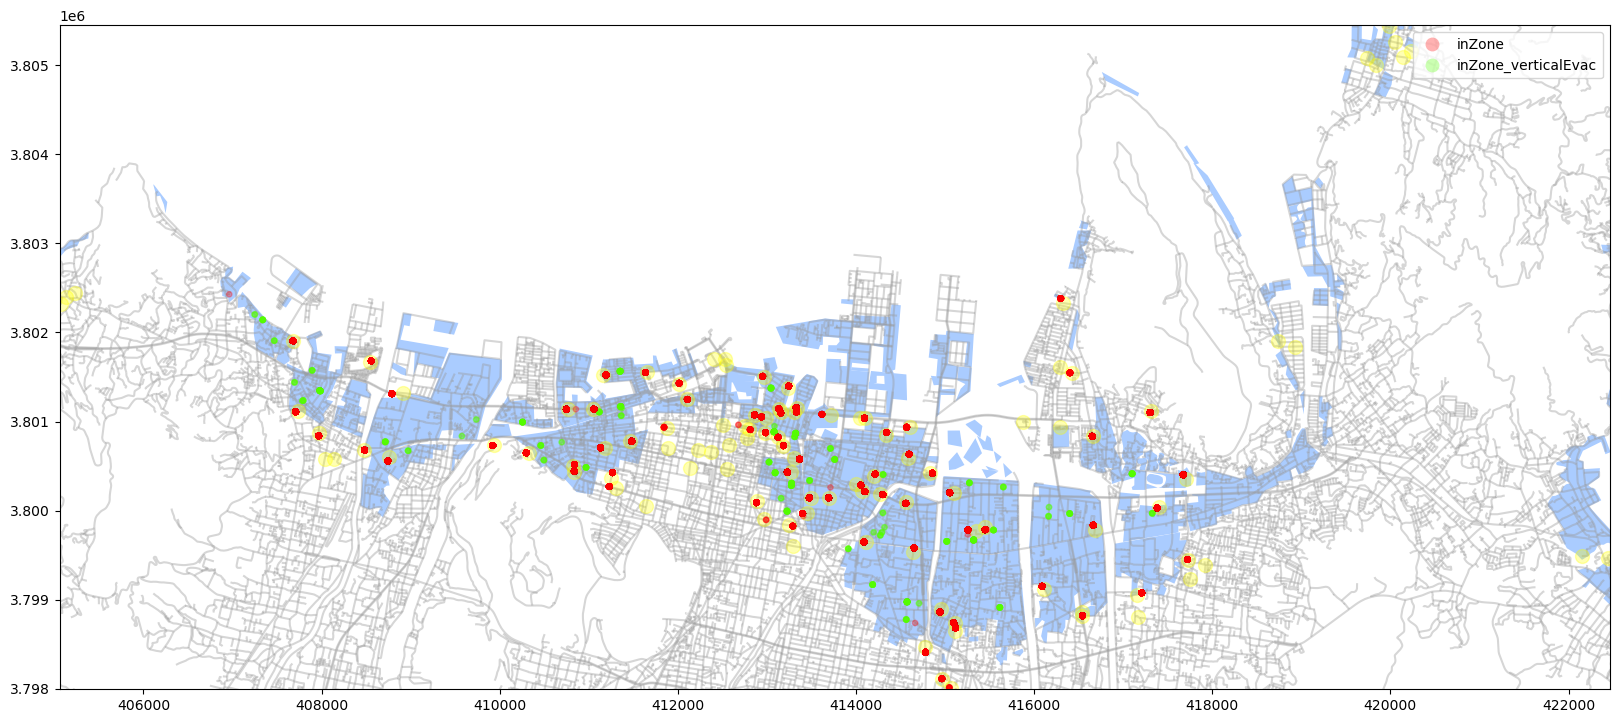

In [208]:
# plot the background and the people

layers = [roads, water, shelters_gdf, gdf]
for l in layers:
    l.set_crs(epsg=6690)

fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4)
water.plot(ax=base, color='#AACCFF')
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, column="flooded", cmap="prism", legend=True, zorder=3, marker='o', markersize=15, alpha=.3)

xmin, ymin, xmax, ymax = shelters_gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


In [222]:
from geopandas import GeoSeries
from shapely.geometry import LineString
from matplotlib.colors import TwoSlopeNorm

# plot the journey information
feats = []
time = []
for g in gdf_homes.itertuples():
    j = LineString([[g.x_home, g.y_home], [g.x_loc, g.y_loc]])
    feats.append(j)
    time.append(extractEvacTime(g.evacuatingRecord, total_sim_time))
journeys = geopandas.GeoDataFrame(geometry=GeoSeries(feats))

time /= np.max(time)
journeys["evacTime"] = time


In [218]:
layers = [roads, water, shelters_gdf, gdf_homes, journeys]
for l in layers:
    l.set_crs(epsg=6690)

In [213]:
hist, bins = np.histogram(journeys['evacTime'])

In [220]:
journeys[journeys["evacTime"] == 1]

,geometry,evacTime
6325,"LINESTRING (415575.000 3799040.000, 416090.000...",1.0
34791,"LINESTRING (415607.000 3798974.000, 416090.000...",1.0
36347,"LINESTRING (415706.000 3799051.000, 416090.000...",1.0
42614,"LINESTRING (415588.000 3798976.000, 416090.000...",1.0
44257,"LINESTRING (415681.000 3799019.000, 416090.000...",1.0
49161,"LINESTRING (415576.000 3799115.000, 416090.000...",1.0


In [147]:
gdf.iloc[25612]["evacuatingRecord"]

'BEGIN_EVACUATING:0.0,EVAC_ORDER_PROMPTED_AT:0,MOVE_TO_HOME_FAILED_BUT_WILL_RETRY:0,ARRIVED_AT_HOME_TO_SHELTER_IN_PLACE:1,SHELTERING_IN_HOME:1,DONE:1,SHELTERING_IN_HOME:2,DONE:2,SET_TO_INUNDATED:60,FLOOD_PROMPTED_AT:60,SHELTERING_IN_HOME:61,DONE:61'

In [226]:
vmin, vmax, vcenter = journeys.evacTime.min(), journeys.evacTime.max(), journeys.evacTime.mean()
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = 'plasma'
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

(3797993.954, 3805450.646)

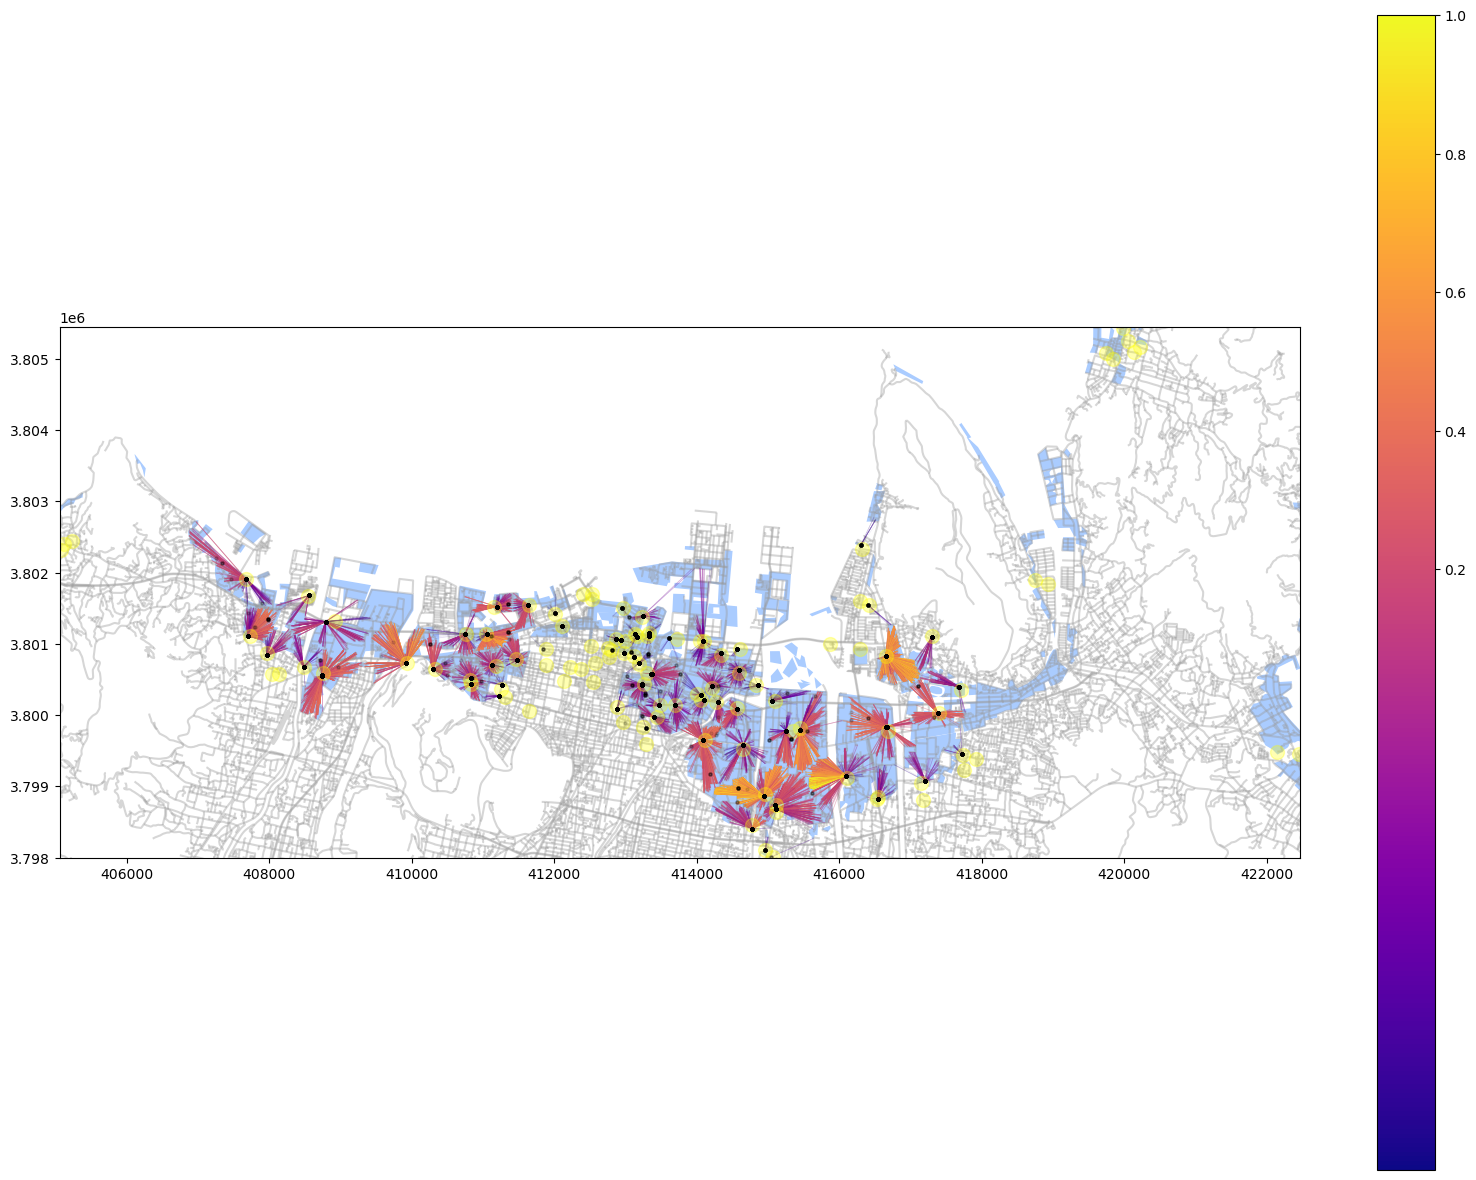

In [230]:
fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4, zorder=-2)
water.plot(ax=base, color='#AACCFF', zorder=-3)
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, legend=True, zorder=3, marker='o', markersize=5, alpha=.05, color='black')##column="flooded", cmap='plasma', )
journeys.plot(ax=base, column="evacTime", zorder=1, linewidth=.5, cmap=cmap, norm=norm, legend=False, alpha=journeys["evacTime"]/vmax)
fig.colorbar(cbar)

xmin, ymin, xmax, ymax = shelters_gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


30 minutes milling around time!

1. journey duration histogram (successful)
2. final location of unsuccessful individuals (+ journey times?)
3. basic info: number of agents

In [233]:
import random
import numpy as np
import math

def r_func(sigma):
    return sigma * math.sqrt(-2 * np.log(random.random()))


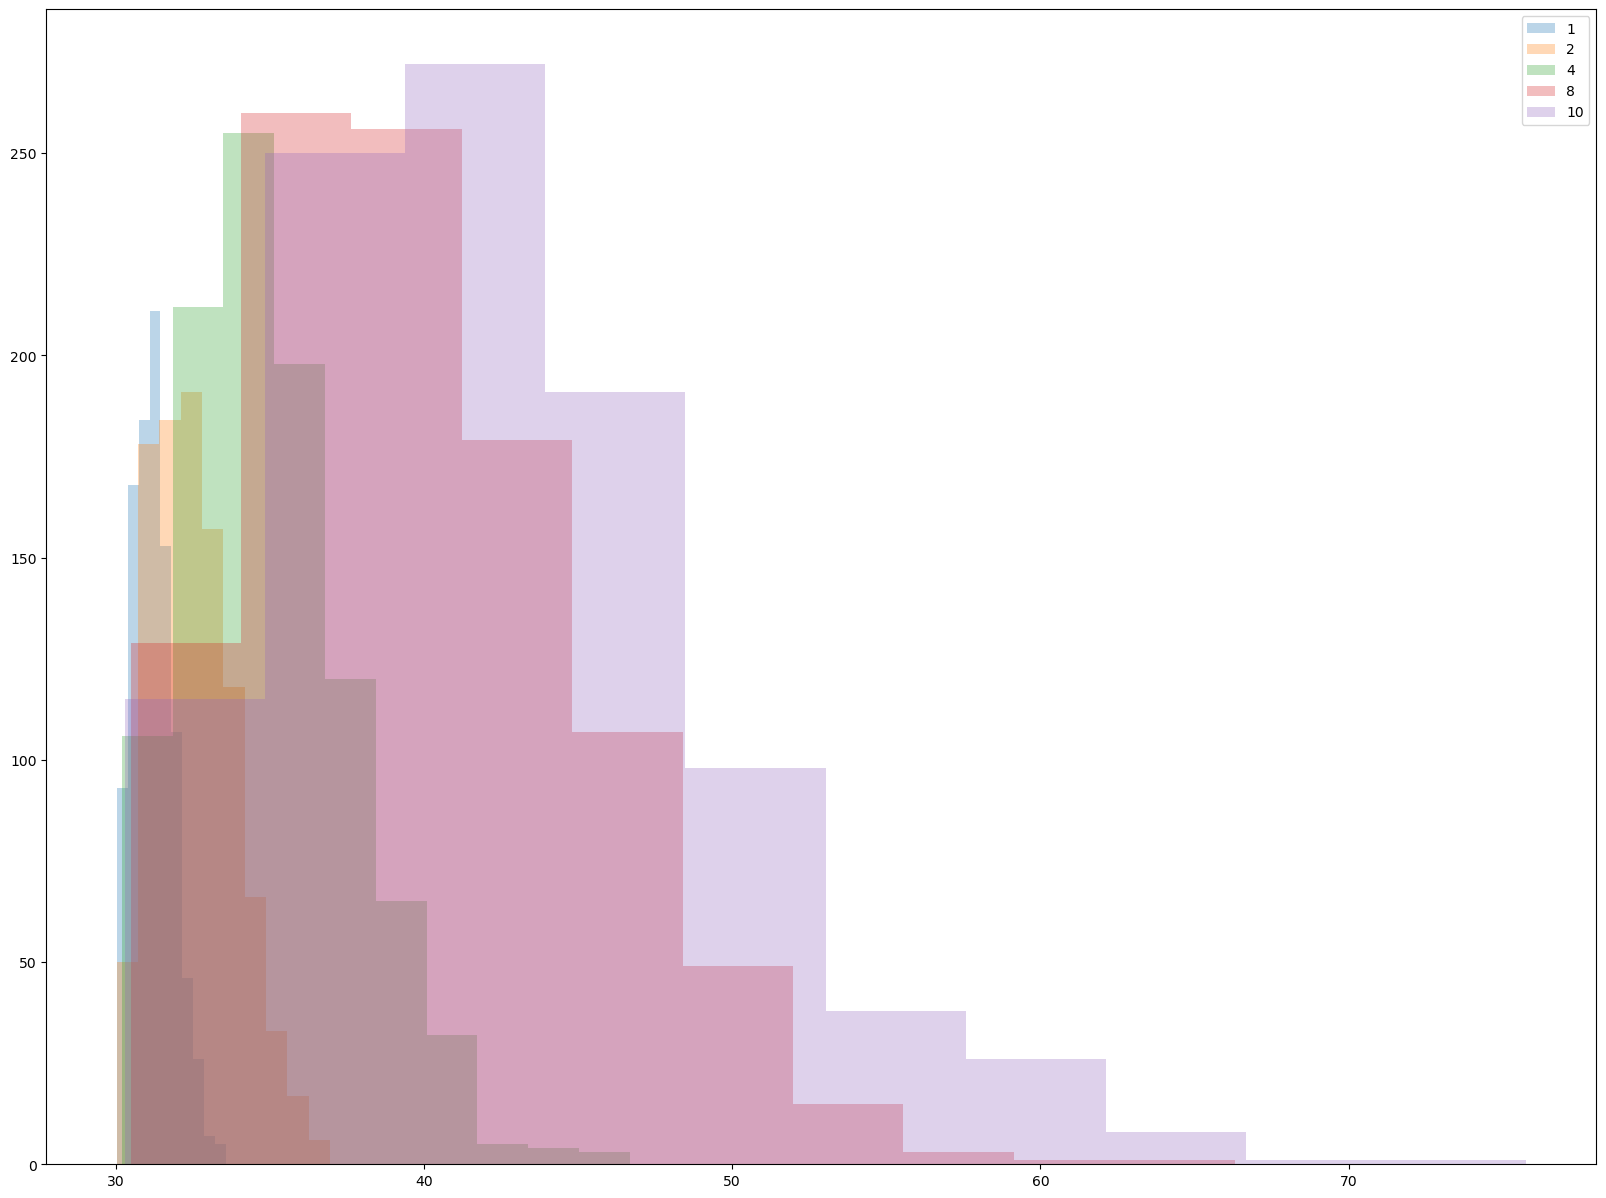

In [257]:
fig, base = plt.subplots(figsize=(20, 15))
size = 1000
for sig in [1, 2, 4, 8, 10]:
    sample = [30 + r_func(sig) for i in range(size)]
    base.hist(sample, alpha = .3, label=sig)#, cumulative=1, density=True, histtype="step")

base.legend()

### Sheltering in place (badly)

In [ ]:
sns.set_style('white')

exportMapByScenario(holder, "hicss_stillEvacuating_flooded.png", "Unfinished Evacuation Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Evacuating']})

Customising label legends: [here](https://stackoverflow.com/questions/74143732/customize-legend-labels-in-geopandas)
MatPlotLib [histogram documentation](https://matplotlib.org/stable/gallery/statistics/histogram_normalization.html)

Changing the markersize?
` cities.plot(markersize=cities['values']) `

[Projection info](https://www.practicaldatascience.org/notebooks/gis/50_gis_crs_geopandas.html) and [working with spatial data](https://earthdatascience.org/courses/earth-analytics-python/spatial-data-vector-shapefiles/python-change-spatial-extent-of-map-matplotlib-geopandas/)
